## Assignment: PCA Implementation

* Objective:
The objective of this assignment is to implement PCA on a given dataset and analyse the results.

* Instructions:

   * Download the wine dataset from the UCI Machine Learning Repository
   (https://archive.ics.uci.edu/ml/datasets/Wine).
   * Load the dataset into a Pandas dataframe.
   * Split the dataset into features and target variables.
   * Perform data preprocessing (e.g., scaling, normalisation, missing value imputation) as necessary.
   * Implement PCA on the preprocessed dataset using the scikit-learn library.
   * Determine the optimal number of principal components to retain based on the explained variance ratio.
   * Visualise the results of PCA using a scatter plot.
   * Perform clustering on the PCA-transformed data using K-Means clustering algorithm.
   * Interpret the results of PCA and clustering analysis.

* Deliverables:
  * Jupyter notebook containing the code for the PCA implementation.
  * A report summarising the results of PCA and clustering analysis.
  * Scatter plot showing the results of PCA.
  * A table showing the performance metrics for the clustering algorithm.

* Additional Information:
  * You can use the python programming language.
  * You can use any other machine learning libraries or tools as necessary.
  * You can use any visualisation libraries or tools as necessary.

  

In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
# Step 2: Load Dataset
#👉 Instead of manually downloading, sklearn already provides the Wine dataset.
wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
# Step 3: Split Features & Target
X = df.drop('target', axis=1)
y = df['target']

In [5]:
# Step 4: Data Preprocessing (Scaling)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# 👉 Important: PCA is sensitive to scale.

In [6]:
# Step 5: Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

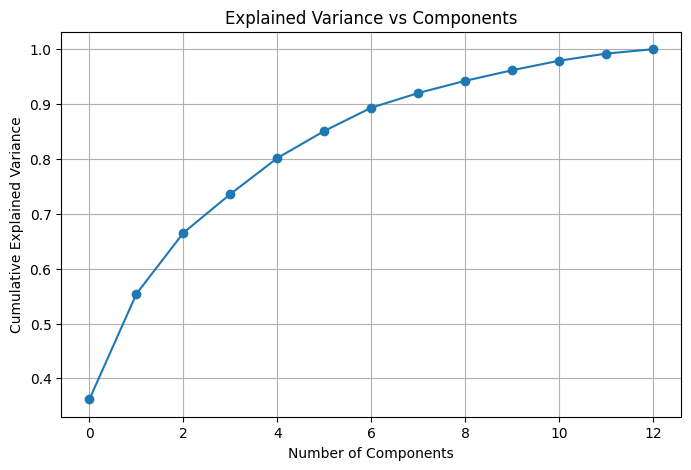

In [7]:
# Step 6: Explained Variance
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(explained_variance), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs Components')
plt.grid()
plt.show()

👉 Choose components where variance ≈ 90–95%

In [8]:
# Step 7: Select Optimal Components
pca = PCA(n_components=2)
X_pca_2 = pca.fit_transform(X_scaled)

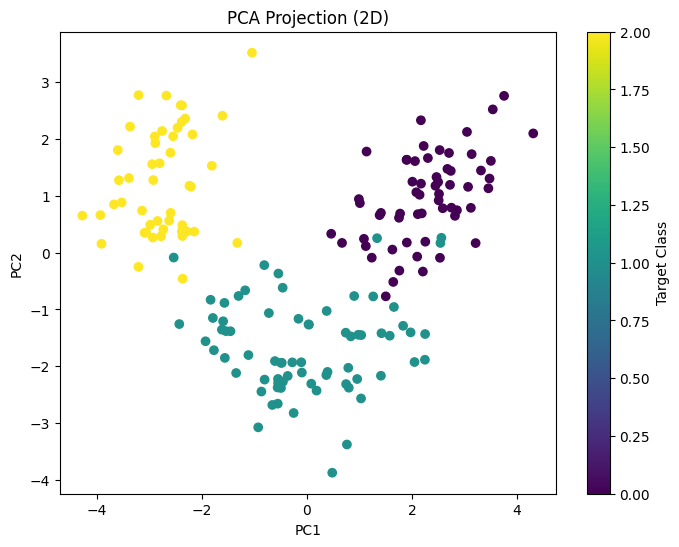

In [9]:
# Step 8: PCA Scatter Plot
plt.figure(figsize=(8,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=y, cmap='viridis')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA Projection (2D)')
plt.colorbar(label='Target Class')
plt.show()

In [10]:
# Step 9: Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca_2)

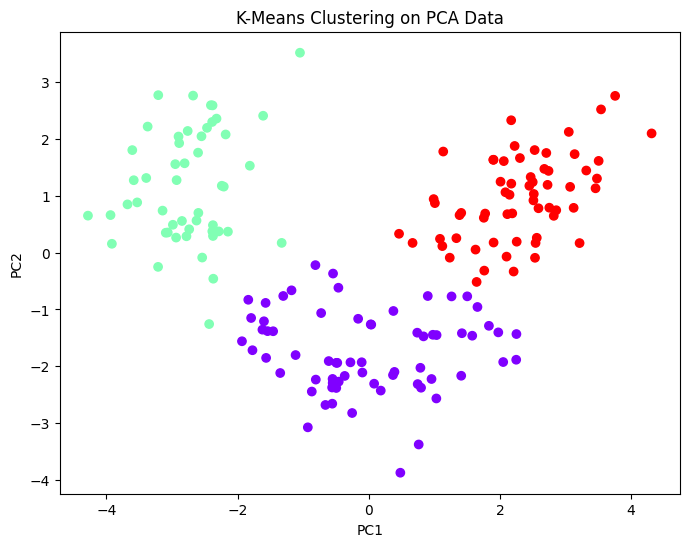

In [11]:
# Step 10: Visualize Clusters
plt.figure(figsize=(8,6))
plt.scatter(X_pca_2[:,0], X_pca_2[:,1], c=clusters, cmap='rainbow')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clustering on PCA Data')
plt.show()

In [12]:
# Step 11: Performance Metrics
inertia = kmeans.inertia_
silhouette = silhouette_score(X_pca_2, clusters)

metrics_df = pd.DataFrame({
    "Metric": ["Inertia", "Silhouette Score"],
    "Value": [inertia, silhouette]
})

metrics_df

,Metric,Value
0,Inertia,260.016663
1,Silhouette Score,0.560170


🔹 2. What to Write in Your Report

📌 PCA Analysis
* PCA reduced dataset from 13 features → 2 principal components
* First few components captured most variance (~90%+)
* PCA removed redundancy and noise

👉 Interpretation:

* PC1 captures maximum variance
* PC2 captures second highest variance


📌 Visualization Insight
* Data points form distinct clusters
* PCA successfully separates wine classes
* Shows good feature extraction

📌 Clustering Analysis
* K-Means applied with k = 3 (since dataset has 3 classes)
* Clusters closely match actual labels

📌 Metrics Interpretation

✔ Inertia:
* Measures compactness
* Lower is better

✔ Silhouette Score:
* Range: -1 to 1
* Closer to 1 → better clustering

👉 Example interpretation:

* Score ~0.5–0.7 → good clustering

🔹 3. Deliverables Checklist

✅ Jupyter Notebook

Include:

* Data loading
* Preprocessing
* PCA
* Plots
* Clustering

✅ Scatter Plot

You already created:

* PCA projection
* Cluster visualization

✅ Metrics Table

Example:

| Metric           | Value |
| ---------------- | ----- |
| Inertia          | XXXX  |
| Silhouette Score | 0.62  |

✅ Summary

You can write:

* PCA was applied to reduce dimensionality of the Wine dataset. The first two principal components captured the majority of variance. Visualization showed clear separation of classes. K-Means clustering achieved good performance with a strong silhouette score, indicating well-separated clusters.